In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

splicing_summary = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/ATSE_mapper/combined_splicing_summary_20250920.tsv"
splicing_summary_df = pd.read_csv(splicing_summary, sep="\t")

splicing_summary_df.head()

,cell_id,dataset,Sample,Total_Reads,Spliced_Reads,Unspliced_Reads
0,F2S4_180926_045_B01,allen_brain,Aligned,2081782,32930,2048852
1,F2S4_180829_110_D01,allen_brain,Aligned,2634106,125158,2508948
2,F2S4_180207_111_E01,allen_brain,Aligned,348662,21856,326806
3,F1S4_170426_096_G01,allen_brain,Aligned,5581282,117604,5463678
4,F1S4_170329_026_F01,allen_brain,Aligned,5878854,205245,5673609


In [2]:
# Calculate proportion of spliced reads     
splicing_summary_df['spliced_proportion'] = splicing_summary_df['Spliced_Reads'] / splicing_summary_df['Total_Reads']

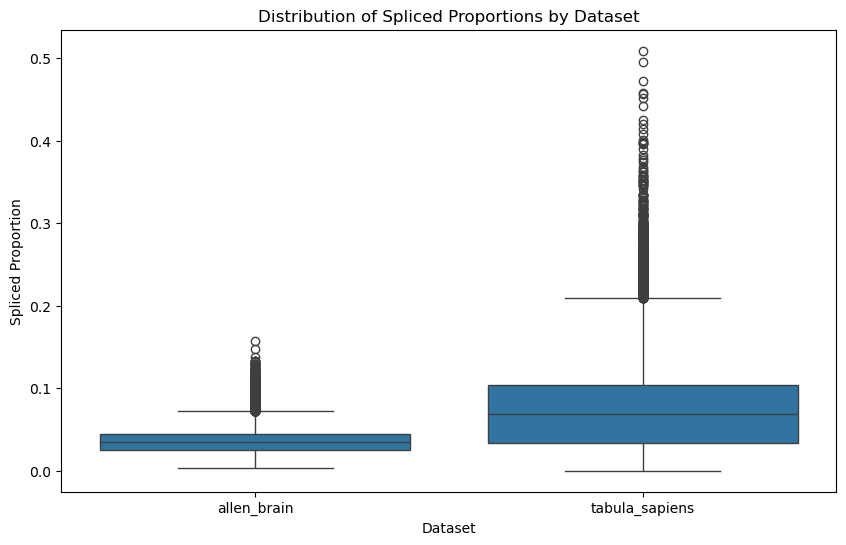

In [4]:
# Plot the distribution of spliced proportions by dataset 
plt.figure(figsize=(10, 6))
sns.boxplot(x='dataset', y='spliced_proportion', data=splicing_summary_df)
plt.title('Distribution of Spliced Proportions by Dataset')
plt.xlabel('Dataset')
plt.ylabel('Spliced Proportion')
plt.show()


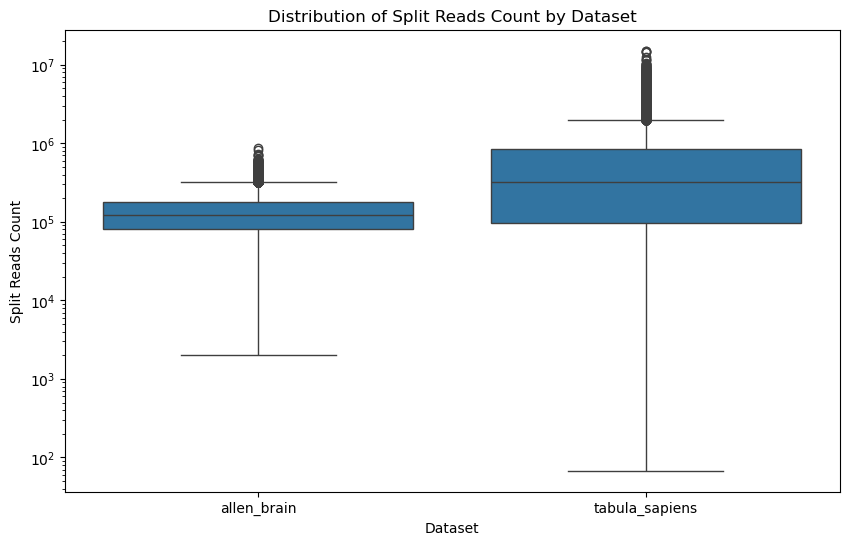

In [5]:
# plot actual counts
plt.figure(figsize=(10, 6))
sns.boxplot(x='dataset', y='Spliced_Reads', data=splicing_summary_df)
plt.title('Distribution of Split Reads Count by Dataset')
plt.xlabel('Dataset')
plt.ylabel('Split Reads Count')
# make sure yaxis is log scale
plt.yscale('log')
plt.show()

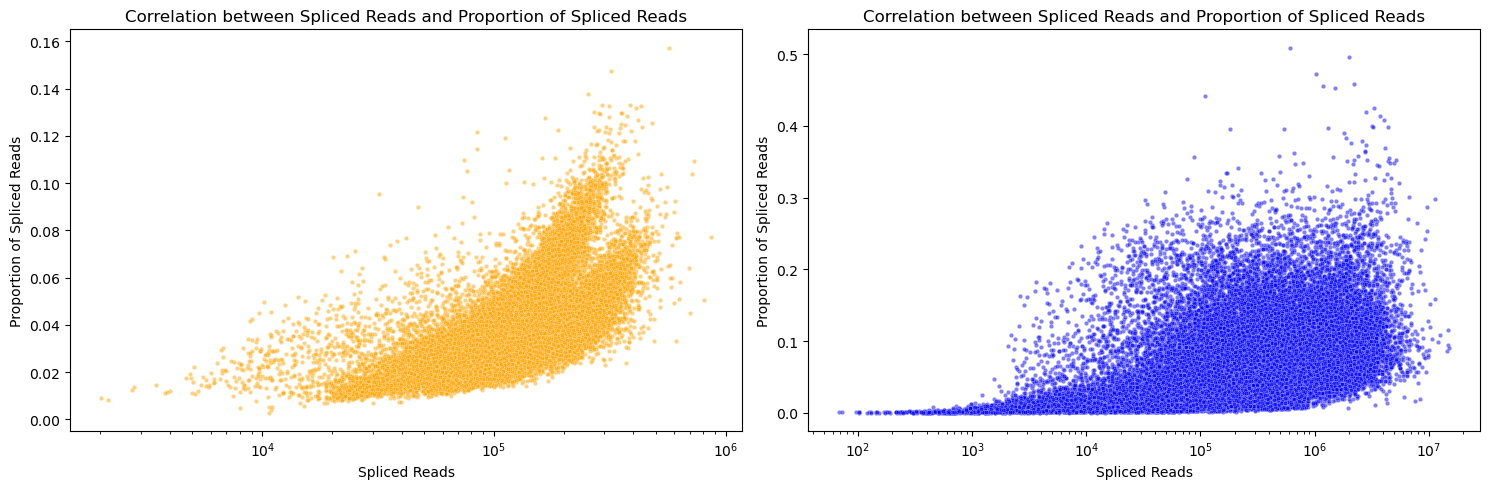

In [12]:
# Plot correlation plot between spliced reads and proportion of spliced reads
# Lets facet them so in one column but two plots same xaxis
# shuffle the rows of the dataframe
splicing_summary_df = splicing_summary_df.sample(frac=1).reset_index(drop=True)

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot the first scatter plot
sns.scatterplot(x='Spliced_Reads', y='spliced_proportion', data=splicing_summary_df[splicing_summary_df["dataset"] == "allen_brain"], color='orange', alpha=0.5, s=10, ax=axes[0])
axes[0].set_title('Correlation between Spliced Reads and Proportion of Spliced Reads')
axes[0].set_xlabel('Spliced Reads') 
axes[0].set_ylabel('Proportion of Spliced Reads')
axes[0].set_xscale('log')

# Plot the second scatter plot
sns.scatterplot(x='Spliced_Reads', y='spliced_proportion', data=splicing_summary_df[splicing_summary_df["dataset"] == "tabula_sapiens"], color='blue', alpha=0.5, s=10, ax=axes[1])
axes[1].set_title('Correlation between Spliced Reads and Proportion of Spliced Reads')
axes[1].set_xlabel('Spliced Reads')
axes[1].set_ylabel('Proportion of Spliced Reads')
axes[1].set_xscale('log')

# Adjust layout
plt.tight_layout()
plt.show()